In [1]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d

In [2]:
#file/prefix definitions
root_dir = "/vision/asomaya1/active-rir/runs"
fs_rir_errors_path = "intermediate_errors_fs_rir_full.json"
active_rir_errors_path = "intermediate_errors_full.json"
tb_dir = "tb"


#Whether to display all models (False) or the average of the US and the average of the SD models (True)
display_averaged_models = False

In [3]:
def smooth_data(x, y, num_points=100, kind='cubic'):
    # Create a spline interpolation
    f = interp1d(x, y, kind=kind)
    # Create new x values
    x_smooth = np.linspace(x[0], x[-1], num=num_points)
    # Compute the smoothed y values
    y_smooth = f(x_smooth)
    return x_smooth, y_smooth

In [4]:
def format_all_trajectories(trajectories, n_obs):
    trajectories = [lst for lst in trajectories if len(lst) > 0]
    # Initialize a list to store the mean values for each key at each step
    mean_values = []
    #Iterate over each step (20 steps)
    for step in range(n_obs):
        step_means = {}
        # Iterate over each trajectory
        for trajectory in trajectories:
            for key, values in list(trajectory[step].items())[:-1]:
                mean = np.mean(np.array(values))
                if key not in step_means:
                    step_means[key] = []
                step_means[key].append(mean)
        
        # Append the dictionary to the mean_values list
        mean_values.append(step_means)

    return mean_values

In [5]:
#choose which run to visualize here. First run in list should have fs_rir_errors computed and stored with it.
runs = ['SD_C_all_subg_queries', 'SD_N_all_subg_queries', 'SD_CNA_all_subg_queries', 'US_C_all_subg_queries', 'US_N_all_subg_queries','US_CNA_all_subg_queries'] # 'US_CNA_all_subg_queries' 'US_CNA_all_subg_queries_RTE_metric', 'US_CN_all_subg_queries'
runs = ['SD_C_all_subg_queries', 'US_CNA_all_subg_queries']
fs_rirs_run = ['SD_C_all_subg_queries']
active_rir_errors_list = []

for run in runs:
    with open(os.path.join(root_dir, run, tb_dir, active_rir_errors_path)) as f:
        active_rir_errors = json.load(f)
        active_rir_errors_list.append(active_rir_errors)

try:
    with open(os.path.join(root_dir, fs_rirs_run[0], tb_dir, fs_rir_errors_path)) as f:
        fs_rir_errors = json.load(f)
except:
    fs_rir_errors = active_rir_errors

In [6]:
active_rir_errors_pref_list = []
episodes = [lst['episode'][1] for lst in active_rir_errors_list[0] if len(lst) > 0]
active_rir_errors = [[lst['metrics'] for lst in active_rir_errors if len(lst) > 0] for active_rir_errors in active_rir_errors_list]
timestamps = [[lst['timestamps'] for lst in active_rir_errors if len(lst) > 0] for active_rir_errors in active_rir_errors_list]
fs_rir_errors = [lst['metrics'] for lst in fs_rir_errors if len(lst) > 0]

In [7]:
n_obs = len(active_rir_errors[0][0]) #ATTN: first run in list should have all N episodes

In [8]:
active_rir_errors = [format_all_trajectories(active_rir_error,n_obs) for active_rir_error in active_rir_errors]
fs_rir_errors = format_all_trajectories(fs_rir_errors, n_obs)

In [9]:
keys_to_plot = ['stft_l1_distance', 'diff_rt_startFrom60dB', 'rel_diff_edt', 'diff_drr_3ms', 'rel_diff_rt_startFrom60dB']

if display_averaged_models:
    us_sums = [None] * 20  # Assuming 20 observations
    sd_sums = [None] * 20  # Assuming 20 observations
    us_count = 0
    sd_count = 0
    timestamps_us = []
    timestamps_sd = []

    # Initialize sums for US and SD models
    for idx, model in enumerate(active_rir_errors):
        model_type = "US" if "US" in runs[idx] else "SD"
        if model_type == "US":
            timestamps_us.append(timestamps[idx])
        if model_type == "SD":
            timestamps_sd.append(timestamps[idx])
        for obs_idx, observation in enumerate(model):
            for metric, values in observation.items():
                # Initialize containers for sums
                if us_sums[obs_idx] is None and model_type == "US":
                    us_sums[obs_idx] = {m: [0]*len(values) for m in keys_to_plot}
                    
                if sd_sums[obs_idx] is None and model_type == "SD":
                    sd_sums[obs_idx] = {m: [0]*len(values) for m in keys_to_plot}

                # Accumulate the sum for each metric and each trajectory
                if model_type == "US":
                    for t_idx, val in enumerate(values):
                        us_sums[obs_idx][metric][t_idx] += val
                    us_count += 1  # Count the number of US models
                elif model_type == "SD":
                    for t_idx, val in enumerate(values):
                        sd_sums[obs_idx][metric][t_idx] += val
                    sd_count += 1  # Count the number of SD models

    # Compute the averages for US and SD models
    us_avg = [{metric: [val / us_count for val in values] for metric, values in observation.items()} for observation in us_sums]
    sd_avg = [{metric: [val / sd_count for val in values] for metric, values in observation.items()} for observation in sd_sums]

    # Overwrite active_rir_errors to contain only these two "averaged" models
    active_rir_errors = [us_avg, sd_avg]
    runs = ['Uniform sampling', 'Active sampling']

    timestamps_us = np.array(timestamps_us)
    avg_timestamps_us = np.mean(timestamps_us, axis=1)

    #TODO: Remove this after adding in 20th observation into ppo_trainer:
    mean_diffs_us = np.diff(avg_timestamps_us, axis=1).mean(axis=1)
    new_column_us = avg_timestamps_us[:, -1] + mean_diffs_us
    padded_avg_timestamps_us = np.column_stack((avg_timestamps_us, new_column_us))

    timestamps_sd = np.array(timestamps_sd)
    avg_timestamps_sd = np.mean(timestamps_sd, axis=1)

    #TODO: Remove this after adding in 20th observation into ppo_trainer:
    mean_diffs_sd = np.diff(avg_timestamps_sd, axis=1).mean(axis=1)
    new_column_sd = avg_timestamps_sd[:, -1] + mean_diffs_sd
    padded_avg_timestamps_sd = np.column_stack((avg_timestamps_sd, new_column_sd))

    padded_avg_timestamps = [np.mean(padded_avg_timestamps_us,axis=0), np.mean(padded_avg_timestamps_sd, axis=0)]

In [10]:
if not display_averaged_models:
    timestamps = np.array(timestamps)
    avg_timestamps = np.mean(timestamps, axis=1)
    #TODO: Remove this after adding in 20th observation into ppo_trainer:
    mean_diffs = np.diff(avg_timestamps, axis=1).mean(axis=1)
    new_column = avg_timestamps[:, -1] + mean_diffs
    padded_avg_timestamps = np.column_stack((avg_timestamps, new_column))

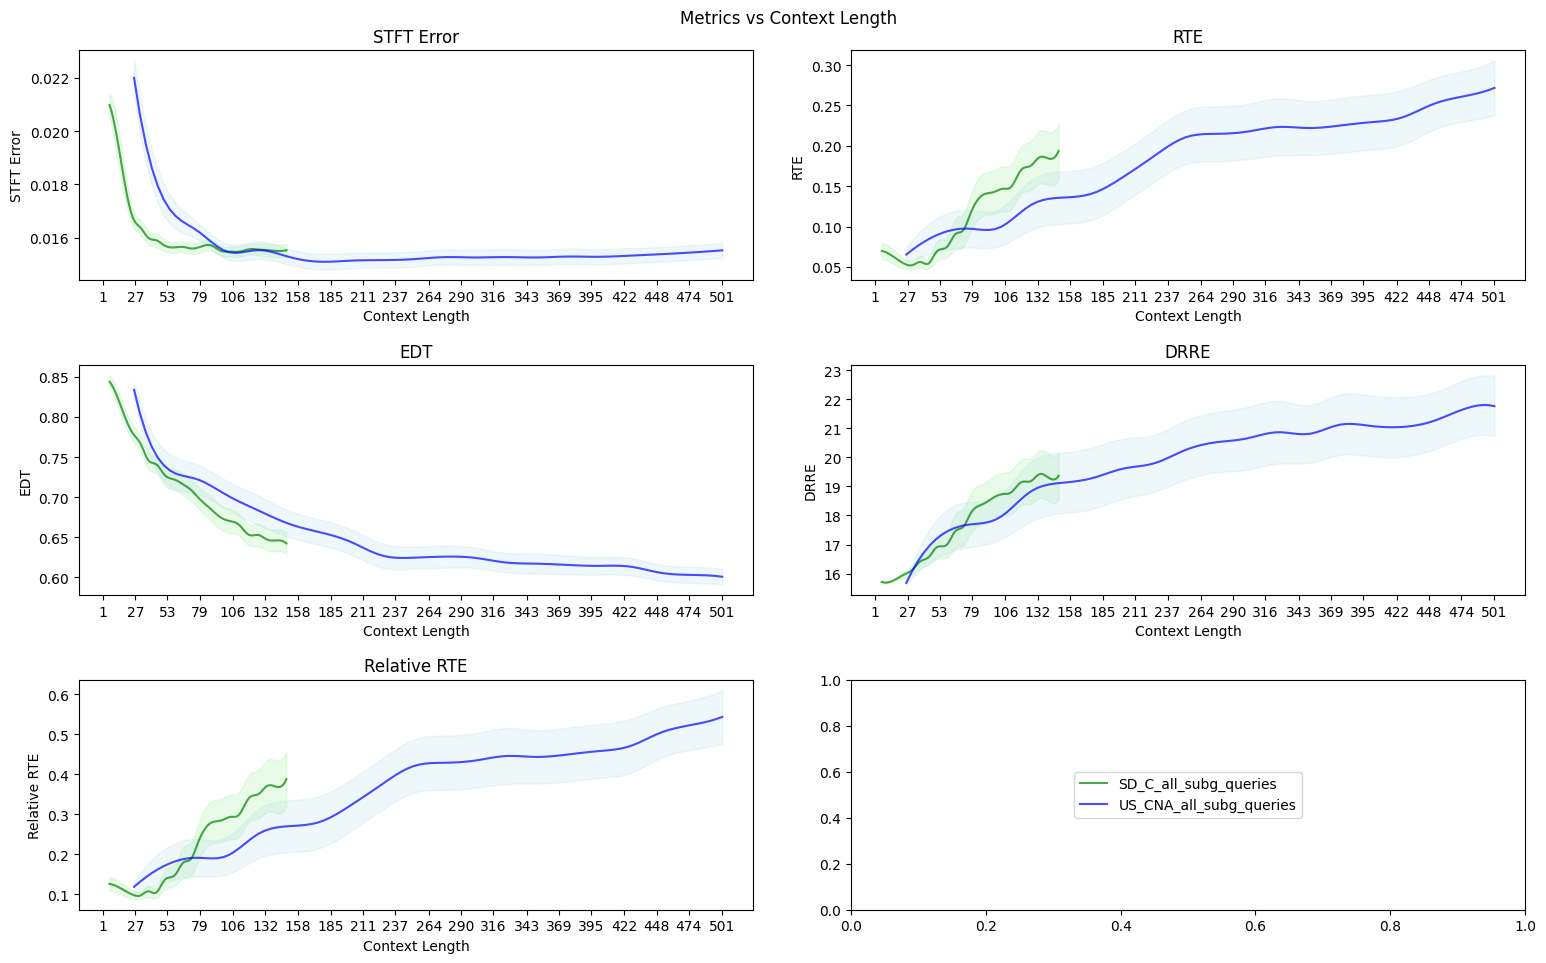

In [11]:
key_short_names = ['STFT Error', 'RTE', 'EDT', 'DRRE', 'Relative RTE']
colors_line = ['green', 'blue', 'red', 'orange', 'pink', 'purple', 'springgreen', 'cyan']
colors_err = ['lightgreen', 'lightblue', 'lightcoral', 'khaki', 'lightpink', 'plum', 'aquamarine', 'mediumturquoise']

fs_rir_mean_metric_stats = {}

# Create subplots for each key
fig, axes = plt.subplots(3,2, figsize=(16, 10))
fig.delaxes(axes[2, 1])
fig.tight_layout(pad=4.0)
legend_labels = []

# Iterate through the keys and plot each one
for i, key in enumerate(keys_to_plot):
    row, col = divmod(i, 2)

    # Extract the values for the current key from all dictionaries
    values_active = []
    for active_rir_error in active_rir_errors:
        values_active.append(np.array([np.array(entry[key]) for entry in active_rir_error]))
    values_fsrir = np.array([np.array(entry[key]) for entry in fs_rir_errors])

    # Calculate the mean values and standard deviations at each position
    mean_active_values = []
    std_active_values = []
    for val_idx, value_active in enumerate(values_active):
        mean_active_values.append(np.mean(value_active, axis=-1))
        std_active_values.append(np.std(value_active, axis=-1) / np.sqrt(len(value_active[0])))

    mean_fsrir_values = np.mean(values_fsrir, axis=-1)
    std_fsrir_values = np.std(values_fsrir, axis=-1)  / np.sqrt(len(values_fsrir[0]))
    fs_rir_mean_metric_stats[key] = mean_fsrir_values[-1]

    # Create the fs_rir x-axis (positions):
    positions_fs_rir = [0, 26, 52, 78, 105, 131, 157, 184, 210, 236, 263, 289, 315, 342, 368, 394, 421, 447, 473, 500]


    x_positions_smooth, mean_active_values_smooth = zip(*[smooth_data(positions, vals) for positions, vals in zip(padded_avg_timestamps, mean_active_values)])
    _, std_active_values_smooth = zip(*[smooth_data(positions, vals) for positions, vals in zip(padded_avg_timestamps, std_active_values)])
    x_positions_smooth_fsrir, mean_fsrir_values_smooth = smooth_data(positions_fs_rir, mean_fsrir_values)
    _, std_fsrir_values_smooth = smooth_data(positions_fs_rir, std_fsrir_values)

    # Plot the mean line (smoothed)
    active_lines = {}
    for idx, vals in enumerate(mean_active_values_smooth):
        active_lines[idx], = axes[row, col].plot(x_positions_smooth[idx], vals, label=f'ActiveRIR (ours)', color=colors_line[idx], alpha=0.7)
    #fsrir_line, = axes[row, col].plot(x_positions_smooth_fsrir, mean_fsrir_values_smooth, label=f'FS-RIR', color='gray', alpha=0.7)

    # Plot the standard deviation as shaded area (smoothed)
    for idx in range(len(mean_active_values_smooth)):
        axes[row, col].fill_between(x_positions_smooth[idx], mean_active_values_smooth[idx] - std_active_values_smooth[idx], mean_active_values_smooth[idx] + std_active_values_smooth[idx], alpha=0.2, color=colors_err[idx])
    #axes[row, col].fill_between(x_positions_smooth_fsrir, mean_fsrir_values_smooth - std_fsrir_values_smooth, mean_fsrir_values_smooth + std_fsrir_values_smooth, alpha=0.2, color='lightgray')

    # Customize plot
    axes[row, col].set_title(f'{key_short_names[i]}')
    axes[row, col].set_xlabel('Context Length')
    axes[row, col].set_ylabel(f'{key_short_names[i]}')
    #axes[i].legend()

    # Set x-axis ticks to integers
    axes[row, col].set_xticks(positions_fs_rir)
    axes[row, col].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x+1)))  # Format as integers


if len(keys_to_plot) % 2 != 0:
    ax_legend = fig.add_subplot(3, 2, 6)
    

for idx, run in enumerate(runs):
    legend_labels.append((active_lines[idx], run))
#legend_labels.append((fsrir_line, "FS-RIR"))

if len(keys_to_plot) % 2 != 0:
    ax_legend.legend(*zip(*legend_labels), loc='center')

plt.suptitle('Metrics vs Context Length ')
plt.show()

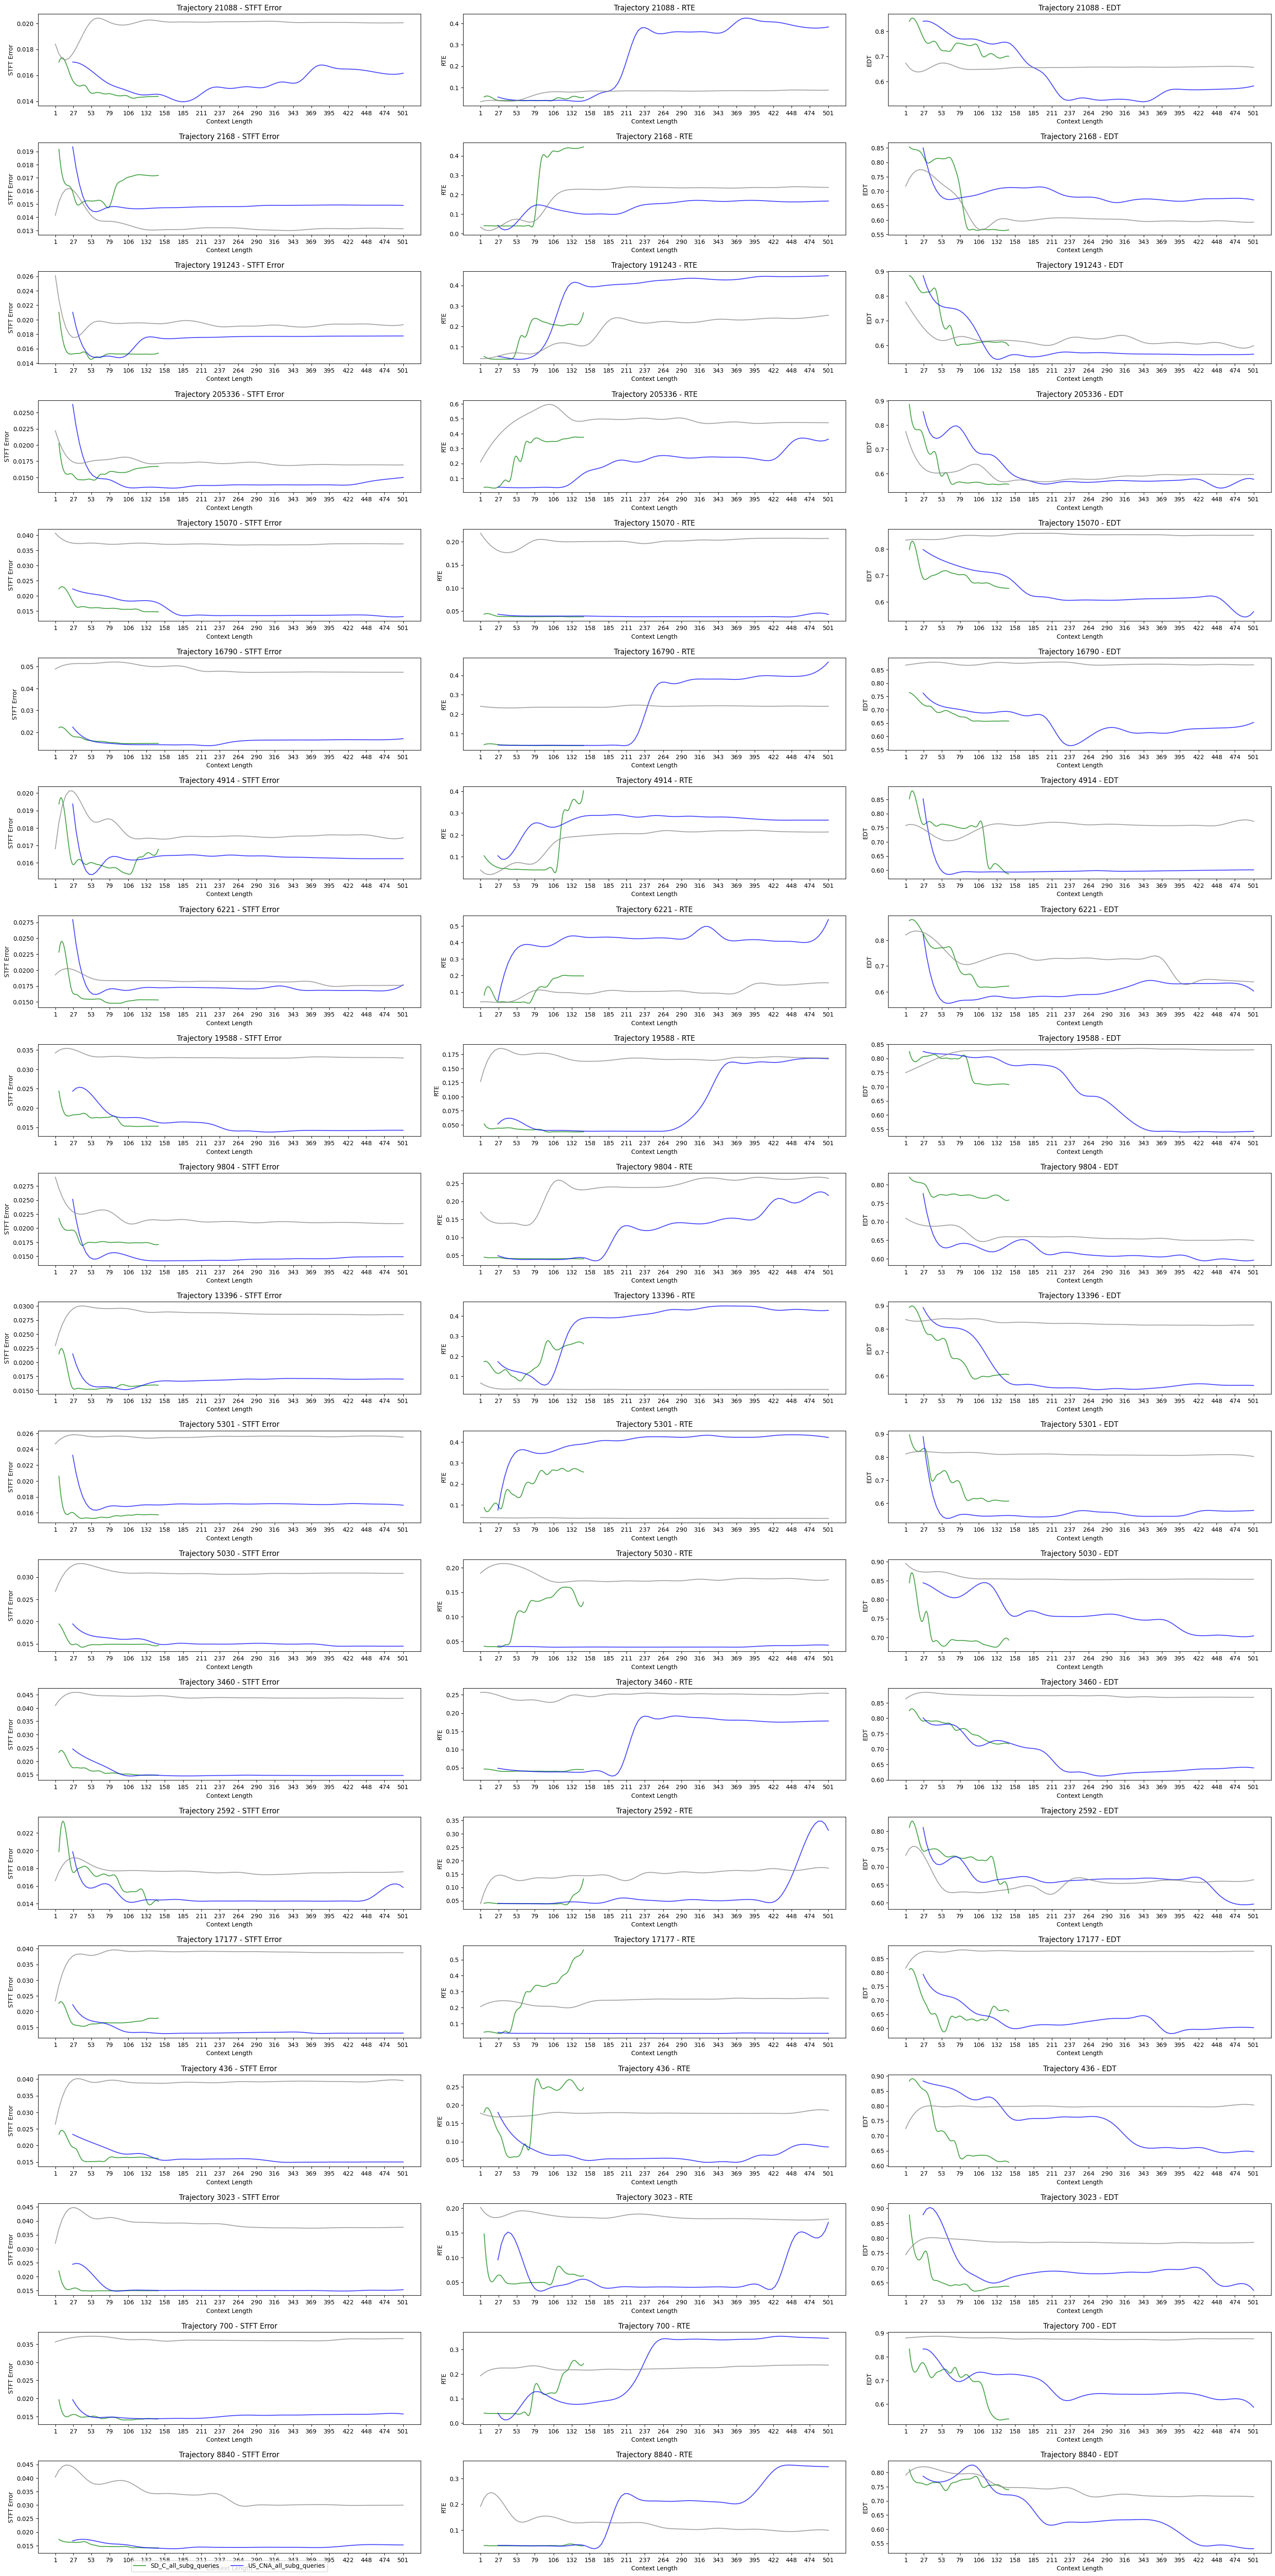

In [12]:
# Number of models
num_models = len(active_rir_errors)
# Number of observations (positions) for each model
num_positions = len(active_rir_errors[0])  # Assuming all models have the same number of positions
# Number of trajectories might vary for each model and metric
# But you can still define the maximum number of trajectories to create the subplots
max_num_trajectories = max(len(model[0][list(model[0].keys())[0]]) for model in active_rir_errors)
fs_rir_errors_per_trajectory = {}
for key in keys_to_plot:
    fs_rir_errors_per_trajectory[key] = []

# Create subplots for the maximum number of trajectories and each key
fig, axes = plt.subplots(max_num_trajectories, len(keys_to_plot[:3]), figsize=(30, max_num_trajectories * 3))  # Adjust figsize as needed
fig.tight_layout(pad=4.0)

# Ensure axes is always a 2D array (needed for a single row of subplots)
if max_num_trajectories == 1:
    axes = [axes]

# Iterate through each trajectory
for traj_idx in range(max_num_trajectories):
    for i, key in enumerate(keys_to_plot[:3]):
        row, col = traj_idx, i

        # Create the x-axis (positions)
        positions = range(num_positions)

        # Iterate through each model
        for model_idx, model in enumerate(active_rir_errors):
            # Check if the trajectory exists for the current model
            if traj_idx < len(model[0][list(model[0].keys())[0]]):
                # Extract the values for the current key for the current trajectory for each position
                values_active = [model[pos][key][traj_idx] for pos in range(num_positions)]

                smoothed_positions, smoothed_values_active = smooth_data(padded_avg_timestamps[model_idx], values_active)
                
                # Plot the line for the current model
                axes[row, col].plot(smoothed_positions, smoothed_values_active, label=f'Model {model_idx+1}', color=colors_line[model_idx], alpha=0.7)

        values_fsrir = [fs_rir_errors[pos][key][traj_idx] for pos in range(num_positions)]
        fs_rir_errors_per_trajectory[key].append(values_fsrir[-1])
        smoothed_positions, smoothed_values_fsrir = smooth_data(positions_fs_rir, values_fsrir)
        axes[row, col].plot(smoothed_positions, smoothed_values_fsrir, label='FS-RIR', color='gray', alpha=0.7)

        # Customize plot for the trajectory if it exists
        if any(traj_idx < len(model[0][list(model[0].keys())[0]]) for model in active_rir_errors):
            axes[row, col].set_title(f'Trajectory {episodes[traj_idx]} - {key_short_names[i]}')
            axes[row, col].set_xlabel('Context Length')
            axes[row, col].set_ylabel(f'{key_short_names[i]}')
            axes[row, col].set_xticks(positions_fs_rir)
            axes[row, col].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x+1)))  # Format as integers
            if traj_idx == max_num_trajectories - 1 and i == 0:
                axes[row, col].legend(*zip(*legend_labels), loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=num_models)  # adjust ncol as needed
        else:
            # Clear the subplot if no trajectory exists for this index
            axes[row, col].axis('off')

plt.show()

In [13]:
import pandas as pd

# Initialize an empty list to store episode data
episodes_data = []

for idx in range(max_num_trajectories):
    # For each episode, create a dictionary with metric names as keys and their values for the episode
    ep_dict = {key: fs_rir_errors_per_trajectory[key][idx] for key in fs_rir_errors_per_trajectory.keys()}
    # Add episode number to the dictionary
    ep_dict['Episode ID'] = episodes[idx]
    # Append the episode data to the list
    episodes_data.append(ep_dict)

# Create a DataFrame from the list of episode data
episodes_df = pd.DataFrame(episodes_data)

# Set the 'Episode' column as the index of the DataFrame
episodes_df.set_index('Episode ID', inplace=True)

IndexError: list index out of range

In [ ]:
print("Per episode stats:")
episodes_df

In [ ]:
print("All episode stats:")
print(episodes_df.mean())